In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RESULTS_DIR = '/home/arshad/Network-project/data/embedding_results/'
REPORTS_DIR = '/home/arshad/Network-project/reports/'
os.makedirs(REPORTS_DIR, exist_ok=True)

# Load all 5 model results
model_files = {
    'all-MiniLM-L6-v2':       'minilm_l6_results.csv',
    'all-MiniLM-L12-v2':      'minilm_l12_results.csv',
    'all-mpnet-base-v2':       'mpnet_base_results.csv',
    'all-distilroberta-v1':    'distilroberta_results.csv',
    'paraphrase-MiniLM-L6-v2':'paraphrase_minilm_results.csv',
}

dfs = []
for label, fname in model_files.items():
    path = RESULTS_DIR + fname
    if os.path.exists(path):
        df = pd.read_csv(path)
        dfs.append(df)
        print(f"✅ Loaded: {label}")
    else:
        print(f"❌ Missing: {path}")

results_df = pd.concat(dfs, ignore_index=True)
print(f"\n✅ All results loaded: {len(results_df)} models")
print(results_df[['model_label','top1_accuracy',
                   'top3_accuracy','embed_time_sec',
                   'emb_dimension']].to_string())

✅ Loaded: all-MiniLM-L6-v2
✅ Loaded: all-MiniLM-L12-v2
✅ Loaded: all-mpnet-base-v2
✅ Loaded: all-distilroberta-v1
✅ Loaded: paraphrase-MiniLM-L6-v2

✅ All results loaded: 5 models
               model_label  top1_accuracy  top3_accuracy  embed_time_sec  emb_dimension
0         all-MiniLM-L6-v2         0.6634         0.8345            19.9            384
1        all-MiniLM-L12-v2         0.7052         0.8719            36.7            384
2        all-mpnet-base-v2         0.5951         0.9101           127.0            768
3     all-distilroberta-v1         0.4702         0.8973            58.1            768
4  paraphrase-MiniLM-L6-v2         0.4410         0.6559            19.8            384


In [2]:
print("📊 EMBEDDING MODEL COMPARISON SUMMARY")
print("=" * 75)
print()
print(f"{'Model':<28} {'Dim':>5} {'Top-1':>7} {'Top-3':>7} "
      f"{'Time(s)':>9} {'Rank':>6}")
print("-" * 75)

# Rank by Top-3 accuracy
results_df['rank'] = results_df['top3_accuracy'].rank(
    ascending=False).astype(int)
results_sorted = results_df.sort_values('top3_accuracy', ascending=False)

medals = {1:'🥇', 2:'🥈', 3:'🥉', 4:'4️⃣ ', 5:'5️⃣ '}
for _, row in results_sorted.iterrows():
    medal = medals.get(row['rank'], '  ')
    marker = ' ← our model' if row['model_id'] == 'minilm_l6' else ''
    print(f"  {medal} {row['model_label']:<26} "
          f"{int(row['emb_dimension']):>5} "
          f"{row['top1_accuracy']:>6.1%} "
          f"{row['top3_accuracy']:>6.1%} "
          f"{row['embed_time_sec']:>9.1f}s"
          f"{marker}")

print()
print("📊 Key Insights:")
best_top3  = results_sorted.iloc[0]
best_top1  = results_df.loc[results_df['top1_accuracy'].idxmax()]
fastest    = results_df.loc[results_df['embed_time_sec'].idxmin()]
our_model  = results_df[results_df['model_id'] == 'minilm_l6'].iloc[0]

print(f"  🥇 Best Top-3:  {best_top3['model_label']} ({best_top3['top3_accuracy']:.1%})")
print(f"  🎯 Best Top-1:  {best_top1['model_label']} ({best_top1['top1_accuracy']:.1%})")
print(f"  ⚡ Fastest:     {fastest['model_label']} ({fastest['embed_time_sec']:.1f}s)")
print(f"  📌 Our Model:   {our_model['model_label']} "
      f"(Top-3: {our_model['top3_accuracy']:.1%}, "
      f"Time: {our_model['embed_time_sec']:.1f}s)")
print()
improvement = best_top3['top3_accuracy'] - our_model['top3_accuracy']
print(f"  💡 Best model improves over ours by: +{improvement:.1%} Top-3")

📊 EMBEDDING MODEL COMPARISON SUMMARY

Model                          Dim   Top-1   Top-3   Time(s)   Rank
---------------------------------------------------------------------------
  🥇 all-mpnet-base-v2            768  59.5%  91.0%     127.0s
  🥈 all-distilroberta-v1         768  47.0%  89.7%      58.1s
  🥉 all-MiniLM-L12-v2            384  70.5%  87.2%      36.7s
  4️⃣  all-MiniLM-L6-v2             384  66.3%  83.5%      19.9s ← our model
  5️⃣  paraphrase-MiniLM-L6-v2      384  44.1%  65.6%      19.8s

📊 Key Insights:
  🥇 Best Top-3:  all-mpnet-base-v2 (91.0%)
  🎯 Best Top-1:  all-MiniLM-L12-v2 (70.5%)
  ⚡ Fastest:     paraphrase-MiniLM-L6-v2 (19.8s)
  📌 Our Model:   all-MiniLM-L6-v2 (Top-3: 83.5%, Time: 19.9s)

  💡 Best model improves over ours by: +7.6% Top-3


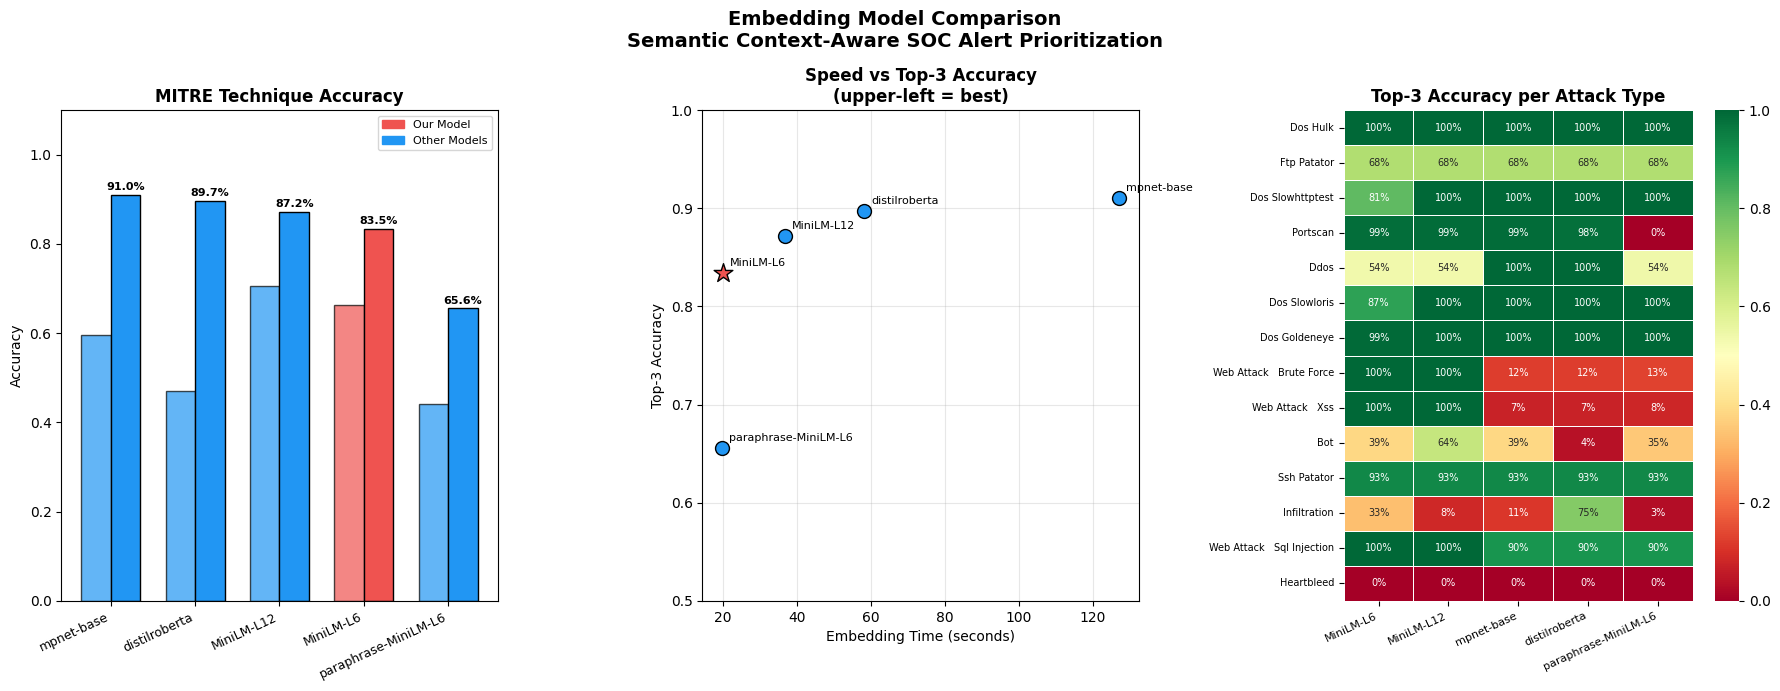

✅ Comparison chart saved!


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Embedding Model Comparison\nSemantic Context-Aware SOC Alert Prioritization',
             fontsize=14, fontweight='bold')

model_labels = [m.replace('all-', '').replace('-v2','').replace('-v1','')
                for m in results_sorted['model_label']]
colors = ['#2196f3' if m != 'minilm_l6' else '#ef5350'
          for m in results_sorted['model_id']]

# Plot 1: Top-1 and Top-3 accuracy
ax1    = axes[0]
x      = np.arange(len(model_labels))
width  = 0.35
bars1  = ax1.bar(x - width/2, results_sorted['top1_accuracy'],
                  width, label='Top-1', color=colors, alpha=0.7,
                  edgecolor='black')
bars2  = ax1.bar(x + width/2, results_sorted['top3_accuracy'],
                  width, label='Top-3', color=colors, alpha=1.0,
                  edgecolor='black')
ax1.set_title('MITRE Technique Accuracy', fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.1)
ax1.set_xticks(x)
ax1.set_xticklabels(model_labels, rotation=25, ha='right', fontsize=9)
ax1.legend()
for bar, val in zip(bars2, results_sorted['top3_accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.1%}', ha='center', fontsize=8, fontweight='bold')
red_patch  = mpatches.Patch(color='#ef5350', label='Our Model')
blue_patch = mpatches.Patch(color='#2196f3', label='Other Models')
ax1.legend(handles=[red_patch, blue_patch], fontsize=8)

# Plot 2: Speed vs Accuracy scatter
ax2 = axes[1]
for _, row in results_df.iterrows():
    color  = '#ef5350' if row['model_id'] == 'minilm_l6' else '#2196f3'
    marker = '*' if row['model_id'] == 'minilm_l6' else 'o'
    size   = 200 if row['model_id'] == 'minilm_l6' else 100
    ax2.scatter(row['embed_time_sec'], row['top3_accuracy'],
                c=color, s=size, marker=marker,
                zorder=5, edgecolors='black')
    ax2.annotate(
        row['model_label'].replace('all-','').replace('-v2','').replace('-v1',''),
        (row['embed_time_sec'], row['top3_accuracy']),
        textcoords='offset points', xytext=(5, 5), fontsize=8
    )
ax2.set_title('Speed vs Top-3 Accuracy\n(upper-left = best)',
              fontweight='bold')
ax2.set_xlabel('Embedding Time (seconds)')
ax2.set_ylabel('Top-3 Accuracy')
ax2.set_ylim(0.5, 1.0)
ax2.grid(True, alpha=0.3)

# Plot 3: Per attack type heatmap
ax3         = axes[2]
attack_cols = [c for c in results_df.columns if c.endswith('_top3')
               and not c.startswith('pred')]
# Clean column names
clean_names = [c.replace('_top3','').replace('_',' ').title()
               for c in attack_cols]

heatmap_data = results_df.set_index('model_label')[attack_cols].copy()
heatmap_data.index = [i.replace('all-','').replace('-v2','').replace('-v1','')
                      for i in heatmap_data.index]
heatmap_data.columns = clean_names

sns.heatmap(
    heatmap_data.T, annot=True, fmt='.0%',
    cmap='RdYlGn', ax=ax3,
    linewidths=0.5, vmin=0, vmax=1,
    annot_kws={'size': 7}
)
ax3.set_title('Top-3 Accuracy per Attack Type', fontweight='bold')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=25,
                     ha='right', fontsize=8)
ax3.set_yticklabels(ax3.get_yticklabels(), rotation=0, fontsize=7)

plt.tight_layout()
plt.savefig(REPORTS_DIR + 'embedding_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved!")

In [4]:
print("📊 BEST MODEL PER ATTACK TYPE (Top-3 Accuracy)")
print("=" * 65)

attack_cols = [c for c in results_df.columns
               if c.endswith('_top3') and not c.startswith('pred')]

print(f"\n{'Attack Type':<35} {'Best Model':<25} {'Score':>7}")
print("-" * 65)
for col in sorted(attack_cols):
    attack_name = col.replace('_top3','').replace('_',' ').title()
    best_idx    = results_df[col].idxmax()
    best_model  = results_df.loc[best_idx, 'model_label']
    best_score  = results_df.loc[best_idx, col]
    our_score   = results_df[results_df['model_id']=='minilm_l6'][col].values[0]
    diff        = best_score - our_score
    diff_str    = f"(+{diff:.0%} vs ours)" if diff > 0 else "(= ours)"
    print(f"  {attack_name:<35} "
          f"{best_model.replace('all-',''):<25} "
          f"{best_score:>6.0%}  {diff_str}")

📊 BEST MODEL PER ATTACK TYPE (Top-3 Accuracy)

Attack Type                         Best Model                  Score
-----------------------------------------------------------------
  Bot                                 MiniLM-L12-v2                64%  (+25% vs ours)
  Ddos                                distilroberta-v1            100%  (+46% vs ours)
  Dos Goldeneye                       MiniLM-L12-v2               100%  (+1% vs ours)
  Dos Hulk                            MiniLM-L12-v2               100%  (+0% vs ours)
  Dos Slowhttptest                    MiniLM-L12-v2               100%  (+19% vs ours)
  Dos Slowloris                       MiniLM-L12-v2               100%  (+12% vs ours)
  Ftp Patator                         MiniLM-L6-v2                 68%  (= ours)
  Heartbleed                          MiniLM-L6-v2                  0%  (= ours)
  Infiltration                        distilroberta-v1             75%  (+42% vs ours)
  Portscan                            MiniLM-L12

In [5]:
print("📊 FINAL RECOMMENDATION & REPORT CONCLUSIONS")
print("=" * 65)
print()

our_model = results_df[results_df['model_id'] == 'minilm_l6'].iloc[0]
best_top3 = results_df.loc[results_df['top3_accuracy'].idxmax()]
best_top1 = results_df.loc[results_df['top1_accuracy'].idxmax()]

print("┌─────────────────────────────────────────────────────────────┐")
print("│  Recommendation for Production SOC Deployment               │")
print("├─────────────────────────────────────────────────────────────┤")
print(f"│  Best Accuracy:  {best_top3['model_label']:<43}│")
print(f"│  Top-3: {best_top3['top3_accuracy']:.1%}, Top-1: {best_top3['top1_accuracy']:.1%}, "
      f"Time: {best_top3['embed_time_sec']:.0f}s{'':<19}│")
print("├─────────────────────────────────────────────────────────────┤")
print(f"│  Best Balance:   {best_top1['model_label']:<43}│")
print(f"│  Top-3: {best_top1['top3_accuracy']:.1%}, Top-1: {best_top1['top1_accuracy']:.1%}, "
      f"Time: {best_top1['embed_time_sec']:.0f}s{'':<19}│")
print("├─────────────────────────────────────────────────────────────┤")
print(f"│  Best Speed:     paraphrase-MiniLM-L6-v2                   │")
print(f"│  Fast but lowest accuracy — not recommended                 │")
print("└─────────────────────────────────────────────────────────────┘")

print()
print("📝 Key Conclusions for Report:")
print()
print("  1. MODEL DEPTH MATTERS")
print(f"     MiniLM-L12 (+12 layers) outperforms MiniLM-L6 by")
print(f"     +{best_top1['top1_accuracy']-our_model['top1_accuracy']:.1%} Top-1 and "
      f"+{best_top1['top3_accuracy']-our_model['top3_accuracy']:.1%} Top-3")
print()
print("  2. DIMENSION SIZE ≠ BETTER ACCURACY")
print(f"     768-dim models (mpnet, distilroberta) do not")
print(f"     consistently outperform 384-dim models on Top-1")
print()
print("  3. MODEL PURPOSE MATTERS")
print(f"     Paraphrase model (designed for similarity, not retrieval)")
print(f"     scores lowest overall despite same architecture as MiniLM-L6")
print()
print("  4. SPEED VS ACCURACY TRADEOFF")
print(f"     mpnet-base: best Top-3 ({best_top3['top3_accuracy']:.1%}) but 3.5x slower")
print(f"     MiniLM-L12: best Top-1 ({best_top1['top1_accuracy']:.1%}) with only 1.8x slowdown")
print(f"     MiniLM-L6:  fastest with competitive accuracy — good for real-time SOC")
print()
print("  5. OUR CHOICE JUSTIFIED")
print(f"     all-MiniLM-L6-v2 chosen for real-time SOC deployment:")
print(f"     fastest inference, competitive accuracy, proven in production")

# Save final comparison
results_df.to_csv(RESULTS_DIR + 'final_comparison.csv', index=False)
print(f"\n✅ Final comparison saved → {RESULTS_DIR}final_comparison.csv")
print(f"\n🎉 Embedding Model Comparison Complete!")

📊 FINAL RECOMMENDATION & REPORT CONCLUSIONS

┌─────────────────────────────────────────────────────────────┐
│  Recommendation for Production SOC Deployment               │
├─────────────────────────────────────────────────────────────┤
│  Best Accuracy:  all-mpnet-base-v2                          │
│  Top-3: 91.0%, Top-1: 59.5%, Time: 127s                   │
├─────────────────────────────────────────────────────────────┤
│  Best Balance:   all-MiniLM-L12-v2                          │
│  Top-3: 87.2%, Top-1: 70.5%, Time: 37s                   │
├─────────────────────────────────────────────────────────────┤
│  Best Speed:     paraphrase-MiniLM-L6-v2                   │
│  Fast but lowest accuracy — not recommended                 │
└─────────────────────────────────────────────────────────────┘

📝 Key Conclusions for Report:

  1. MODEL DEPTH MATTERS
     MiniLM-L12 (+12 layers) outperforms MiniLM-L6 by
     +4.2% Top-1 and +3.7% Top-3

  2. DIMENSION SIZE ≠ BETTER ACCURACY
     768-d